In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
sales_df=pd.read_csv("sales_data.csv")
sales_df.head()

,Order_ID,Customer_ID,Product,Region,Quantity,Unit_Price,Order_Date,Revenue
0,1001,27,Accessories,West,5,60000,2024-01-01,300000
1,1002,17,Laptop,East,4,60000,2024-01-02,240000
2,1003,9,Tablet,North,5,15000,2024-01-03,75000
3,1004,33,Laptop,South,4,15000,2024-01-04,60000
4,1005,20,Accessories,South,5,8000,2024-01-05,40000


In [4]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Order_ID     150 non-null    int64 
 1   Customer_ID  150 non-null    int64 
 2   Product      150 non-null    object
 3   Region       150 non-null    object
 4   Quantity     150 non-null    int64 
 5   Unit_Price   150 non-null    int64 
 6   Order_Date   150 non-null    object
 7   Revenue      150 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 9.5+ KB


In [5]:
sales_df.isnull().sum()

Order_ID       0
Customer_ID    0
Product        0
Region         0
Quantity       0
Unit_Price     0
Order_Date     0
Revenue        0
dtype: int64

In [7]:
sales_df["Revenue"]=sales_df["Quantity"]*sales_df["Unit_Price"]
sales_df.head()

,Order_ID,Customer_ID,Product,Region,Quantity,Unit_Price,Order_Date,Revenue
0,1001,27,Accessories,West,5,60000,2024-01-01,300000
1,1002,17,Laptop,East,4,60000,2024-01-02,240000
2,1003,9,Tablet,North,5,15000,2024-01-03,75000
3,1004,33,Laptop,South,4,15000,2024-01-04,60000
4,1005,20,Accessories,South,5,8000,2024-01-05,40000


In [8]:
customer_features=sales_df.groupby("Customer_ID").agg({
    "Revenue":"sum",
    "Order_ID":"count",
    "Quantity":"sum"
}).reset_index()
customer_features.rename(columns={"Order_ID":"Total_Orders"},inplace=True)
customer_features.head()

,Customer_ID,Revenue,Total_Orders,Quantity
0,1,980000,7,24
1,2,337000,3,12
2,3,152000,4,9
3,4,113000,4,5
4,5,521000,9,24


In [13]:
customer_features["Avg_Order_Value"]=(
    customer_features["Revenue"]/customer_features["Total_Orders"]
)
customer_features.head()

,Customer_ID,Revenue,Total_Orders,Quantity,Avgg_Order_Value,Avg_Order_Value
0,1,980000,7,24,140000.000000,140000.000000
1,2,337000,3,12,112333.333333,112333.333333
2,3,152000,4,9,38000.000000,38000.000000
3,4,113000,4,5,28250.000000,28250.000000
4,5,521000,9,24,57888.888889,57888.888889


In [14]:
import os
os.makedirs("outputs", exist_ok=True)

customer_features.to_csv("outputs/customer_features.csv", index=False)


In [15]:
customer_features.columns


Index(['Customer_ID', 'Revenue', 'Total_Orders', 'Quantity',
       'Avgg_Order_Value', 'Avg_Order_Value'],
      dtype='object')

In [16]:
X = customer_features[["Revenue", "Total_Orders", "Quantity", "Avg_Order_Value"]]
X.head()

,Revenue,Total_Orders,Quantity,Avg_Order_Value
0,980000,7,24,140000.000000
1,337000,3,12,112333.333333
2,152000,4,9,38000.000000
3,113000,4,5,28250.000000
4,521000,9,24,57888.888889


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [18]:
X_scaled[:5]


array([[ 2.6790381 ,  1.69465863,  2.09731373,  1.28699955],
       [ 0.00437298, -0.45466451,  0.09416511,  0.63176788],
       [-0.76516519,  0.08266627, -0.40662205, -1.12867383],
       [-0.92739216,  0.08266627, -1.07433826, -1.35958378],
       [ 0.76975149,  2.7693202 ,  2.09731373, -0.65764383]])

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
customer_features["Segment"] = kmeans.fit_predict(X_scaled)

customer_features.head()


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Customer_ID,Revenue,Total_Orders,Quantity,Avgg_Order_Value,Avg_Order_Value,Segment
0,1,980000,7,24,140000.000000,140000.000000,1
1,2,337000,3,12,112333.333333,112333.333333,2
2,3,152000,4,9,38000.000000,38000.000000,0
3,4,113000,4,5,28250.000000,28250.000000,0
4,5,521000,9,24,57888.888889,57888.888889,1


In [20]:
customer_features["Segment"].value_counts()


Segment
0    20
2    11
1     8
Name: count, dtype: int64

In [21]:
customer_features["Segment"].value_counts()


Segment
0    20
2    11
1     8
Name: count, dtype: int64

In [22]:
customer_features.to_csv("outputs/customer_segments.csv", index=False)


In [23]:
customer_features.groupby("Segment")["Revenue"].sum()


Segment
0    3302000
1    5662000
2    4138000
Name: Revenue, dtype: int64

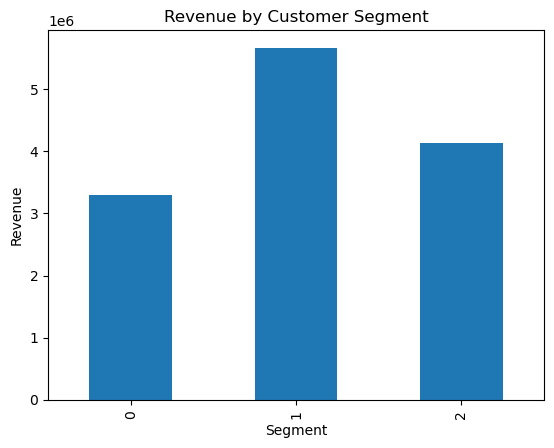

In [24]:
customer_features.groupby("Segment")["Revenue"].sum().plot(kind="bar")
plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.show()


In [25]:
customer_features.sort_values("Revenue", ascending=False).head(10)


,Customer_ID,Revenue,Total_Orders,Quantity,Avgg_Order_Value,Avg_Order_Value,Segment
0,1,980000,7,24,140000.000000,140000.000000,1
32,34,940000,8,26,117500.000000,117500.000000,1
25,27,840000,5,23,168000.000000,168000.000000,1
19,21,736000,6,19,122666.666667,122666.666667,1
8,10,580000,5,19,116000.000000,116000.000000,1
11,13,545000,5,13,109000.000000,109000.000000,2
24,26,539000,6,20,89833.333333,89833.333333,1
15,17,526000,8,20,65750.000000,65750.000000,1
4,5,521000,9,24,57888.888889,57888.888889,1
16,18,520000,4,16,130000.000000,130000.000000,2


In [27]:
customer_features.head()


,Customer_ID,Revenue,Total_Orders,Quantity,Avgg_Order_Value,Avg_Order_Value,Segment
0,1,980000,7,24,140000.000000,140000.000000,1
1,2,337000,3,12,112333.333333,112333.333333,2
2,3,152000,4,9,38000.000000,38000.000000,0
3,4,113000,4,5,28250.000000,28250.000000,0
4,5,521000,9,24,57888.888889,57888.888889,1
